# 02 - Bayesian Calibration of the Heston Model

**Author:** Rodrigo Antonio Salado Ferrero  
**Last Updated:** 2026-05-15

---

## Overview

This notebook performs Bayesian calibration of the Heston stochastic volatility
model using synthetic option price data generated in Notebook 01. The calibration
recovers the posterior distributions of the five Heston parameters:

- **κ (kappa)**: Mean reversion speed
- **θ (theta)**: Long-run variance  
- **ξ (xi)**: Volatility of volatility
- **ρ (rho)**: Correlation (leverage effect)
- **v₀ (v0)**: Initial variance

## Methodology

Bayes' theorem: `p(θ | data) ∝ p(data | θ) · p(θ)`

- **Likelihood**: Gaussian observation errors on option prices
- **Priors**: Mildly informative distributions with domain constraints
- **Posterior**: Sampled via Adaptive Metropolis-Hastings MCMC

## Algorithm: Adaptive Metropolis-Hastings

1. Run a pilot chain with diagonal proposal covariance
2. Estimate posterior covariance from pilot samples
3. Scale covariance by 2.38²/d (Roberts-Gelman-Gilks optimal scaling)
4. Run production chain with tuned multivariate Gaussian proposal

---

## 1. Imports and Configuration

Load all required libraries and configure paths for data I/O.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, lognorm
from typing import Tuple, Optional, Dict, Any, Callable
from dataclasses import dataclass, field
import json
import time
import warnings
from pathlib import Path

# Import local modules
import sys
sys.path.append('..')

from src.pricing import heston_call_prices, black_scholes_call, implied_volatility
from src.types import HestonParams, MarketData, CalibrationResult
from src.inference import (
    LogPrior, LogLikelihood, LogPosterior,
    MetropolisHastingsSampler, AdaptiveMetropolisHastings, calibrate_heston
)
from src.visualization import (
    set_style, plot_trace, plot_posterior_density,
    plot_pair_grid, plot_posterior_predictive, plot_calibration_summary
)

# Set random seed for reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)

# Configure paths
DATA_DIR = Path("../data/synthetic")
RESULTS_DIR = Path("../results")
CHAINS_DIR = RESULTS_DIR / "chains"
FIGURES_DIR = RESULTS_DIR / "figures"

# Create directories if they don't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
CHAINS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting style
set_style(style="seaborn-v0_8-darkgrid", context="notebook", font_scale=1.0)

print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Chains directory: {CHAINS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Random seed set to: {RANDOM_SEED}")

Data directory: ..\data\synthetic
Results directory: ..\results
Chains directory: ..\results\chains
Figures directory: ..\results\figures
Random seed set to: 42


## 2. Load Synthetic Market Data

Load the synthetic option price data generated in Notebook 01.

In [2]:
# Load synthetic data from NPZ file
data_path = DATA_DIR / "synthetic_market_data.npz"

if not data_path.exists():
    raise FileNotFoundError(f"Synthetic data not found at {data_path}.\n"
                            f"Please run notebook 01 first to generate the data.")

with np.load(data_path) as data:
    strikes = data['strikes']
    observed_prices = data['observed_prices']
    spot = float(data['spot'])
    rate = float(data['rate'])
    tenor = float(data['tenor'])
    true_kappa = float(data['kappa'])
    true_theta = float(data['theta'])
    true_xi = float(data['xi'])
    true_rho = float(data['rho'])
    true_v0 = float(data['v0'])
    noise_std = float(data['noise_std'])
    random_seed = int(data['random_seed'])

# Create MarketData object
market_data = MarketData(
    strikes=strikes,
    prices=observed_prices,
    spot=spot,
    rate=rate,
    tenor=tenor,
)

# Store true parameters for validation
true_params_dict = {
    "kappa": true_kappa,
    "theta": true_theta,
    "xi": true_xi,
    "rho": true_rho,
    "v0": true_v0,
}

print("=" * 60)
print("LOADED SYNTHETIC MARKET DATA")
print("=" * 60)
print(f"Source: {data_path}")
print(f"Number of options: {market_data.n_options}")
print(f"Spot price: {market_data.spot}")
print(f"Risk-free rate: {market_data.rate:.4f}")
print(f"Time to maturity: {market_data.tenor} years")
print(f"Strike range: [{strikes.min():.0f}, {strikes.max():.0f}]")
print(f"Noise standard deviation: {noise_std}")
print(f"\nTrue parameters (for validation):")
for name, value in true_params_dict.items():
    print(f"  {name}: {value}")
print("=" * 60)

LOADED SYNTHETIC MARKET DATA
Source: ..\data\synthetic\synthetic_market_data.npz
Number of options: 9
Spot price: 100.0
Risk-free rate: 0.0300
Time to maturity: 1.0 years
Strike range: [80, 120]
Noise standard deviation: 0.05

True parameters (for validation):
  kappa: 2.0
  theta: 0.04
  xi: 0.3
  rho: -0.7
  v0: 0.04


## 3. Visualise Market Data

Plot the implied volatility smile of the observed market data.

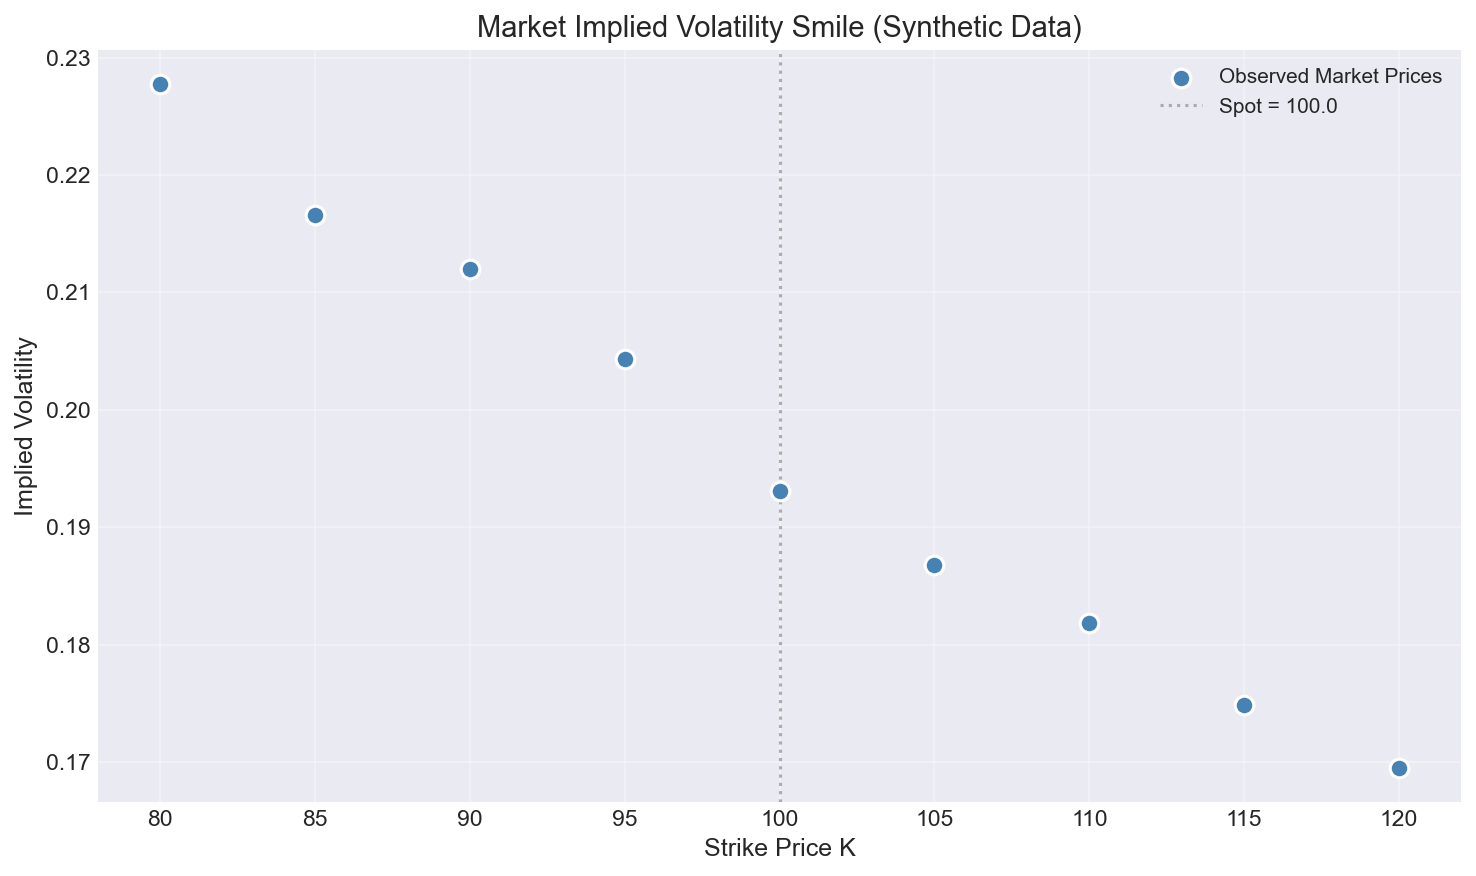

ATM implied volatility (K=100.0): 0.1931


In [3]:
# Compute implied volatilities for observed prices
observed_iv = np.array([
    implied_volatility(p, spot, K, rate, tenor)
    for K, p in zip(strikes, observed_prices)
])

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(strikes, observed_iv, color='steelblue', s=80, zorder=4,
           label='Observed Market Prices', edgecolors='white', linewidths=1.5)

ax.axvline(spot, color='gray', linestyle=':', alpha=0.6, label=f'Spot = {spot}')

ax.set_xlabel('Strike Price K', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('Market Implied Volatility Smile (Synthetic Data)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ATM implied volatility (K={spot}): {observed_iv[4]:.4f}")

## 4. Bayesian Calibration

Run the Adaptive Metropolis-Hastings MCMC sampler to recover the
posterior distributions of the Heston parameters.

In [4]:
# Calibration configuration
SIGMA_NOISE: float = noise_std  # Use the same noise level as data generation

print("=" * 70)
print("HESTON MODEL BAYESIAN CALIBRATION")
print("=" * 70)
print(f"\nMarket data: {market_data.n_options} options")
print(f"  Spot: {market_data.spot}")
print(f"  Rate: {market_data.rate:.4f}")
print(f"  Tenor: {market_data.tenor} years")
print(f"  Strikes: [{strikes[0]:.0f}, ..., {strikes[-1]:.0f}]")
print(f"a noise: {SIGMA_NOISE:.3f}")
print()

# Run calibration
start_time = time.time()

result = calibrate_heston(
    market_data=market_data,
    sigma_noise=SIGMA_NOISE,
    true_params=HestonParams(**true_params_dict),
    verbose=True,
)

runtime = time.time() - start_time
print(f"\nTotal calibration time: {runtime:.2f} seconds")

HESTON MODEL BAYESIAN CALIBRATION

Market data: 9 options
  Spot: 100.0
  Rate: 0.0300
  Tenor: 1.0 years
  Strikes: [80, ..., 120]
a noise: 0.050


HESTON MODEL BAYESIAN CALIBRATION

Market data: 9 options
  Spot: 100.0
  Rate: 0.0300
  Tenor: 1.0 years
  Strikes: [80, ..., 120]
Sigma noise: 0.050

Running pilot chain: 10000 iterations
  Iteration 1000/10000 | Accept: 25.0% | Elapsed: 0.7s | ETA: 6.1s
  Iteration 2000/10000 | Accept: 23.8% | Elapsed: 1.3s | ETA: 5.4s
  Iteration 3000/10000 | Accept: 23.2% | Elapsed: 2.0s | ETA: 4.7s
  Iteration 4000/10000 | Accept: 22.1% | Elapsed: 2.7s | ETA: 4.0s
  Iteration 5000/10000 | Accept: 21.9% | Elapsed: 3.3s | ETA: 3.3s
  Iteration 6000/10000 | Accept: 21.4% | Elapsed: 4.0s | ETA: 2.6s
  Iteration 7000/10000 | Accept: 21.5% | Elapsed: 4.6s | ETA: 2.0s
  Iteration 8000/10000 | Accept: 21.6% | Elapsed: 5.3s | ETA: 1.3s
  Iteration 9000/10000 | Accept: 21.3% | Elapsed: 5.9s | ETA: 0.7s
  Iteration 10000/10000 | Accept: 21.0% | Elapsed: 6.5s | 

## 5. Save Calibration Results

Store the MCMC samples and metadata for later analysis.

In [5]:
# Save results to NPZ file
timestamp = time.strftime("%Y%m%d_%H%M%S")
result_path = CHAINS_DIR / f"calibration_result_{timestamp}.npz"

result.save(str(result_path))
print(f"Saved calibration results to: {result_path}")

# Also save a copy with fixed name for easy access
latest_path = CHAINS_DIR / "latest_calibration.npz"
result.save(str(latest_path))
print(f"Saved as latest: {latest_path}")

# Display summary
result.summary()

Saved calibration results to: ..\results\chains\calibration_result_20260518_120023.npz
Saved as latest: ..\results\chains\latest_calibration.npz

HESTON MODEL CALIBRATION RESULTS

True parameters: {'kappa': 2.0, 'theta': 0.04, 'xi': 0.3, 'rho': -0.7, 'v0': 0.04}

Posterior summary (n_samples=50000):
Acceptance rate: 3.1%
Runtime: 57.39 seconds

----------------------------------------------------------------------
   Param       Mean        Std       2.5%      97.5%
----------------------------------------------------------------------
   kappa     2.5136     0.9461     1.0499     4.7173
   theta     0.0409     0.0107     0.0198     0.0614
      xi     0.3567     0.0774     0.2262     0.5110
     rho    -0.6899     0.1044    -0.9511    -0.5320
      v0     0.0391     0.0157     0.0095     0.0705
----------------------------------------------------------------------


## 6. Convergence Diagnostics - Trace Plots

Trace plots show the evolution of each parameter over MCMC iterations.
A well-mixed chain should look like a "fuzzy caterpillar" with no
visible trends, drifts, or distinct phases.

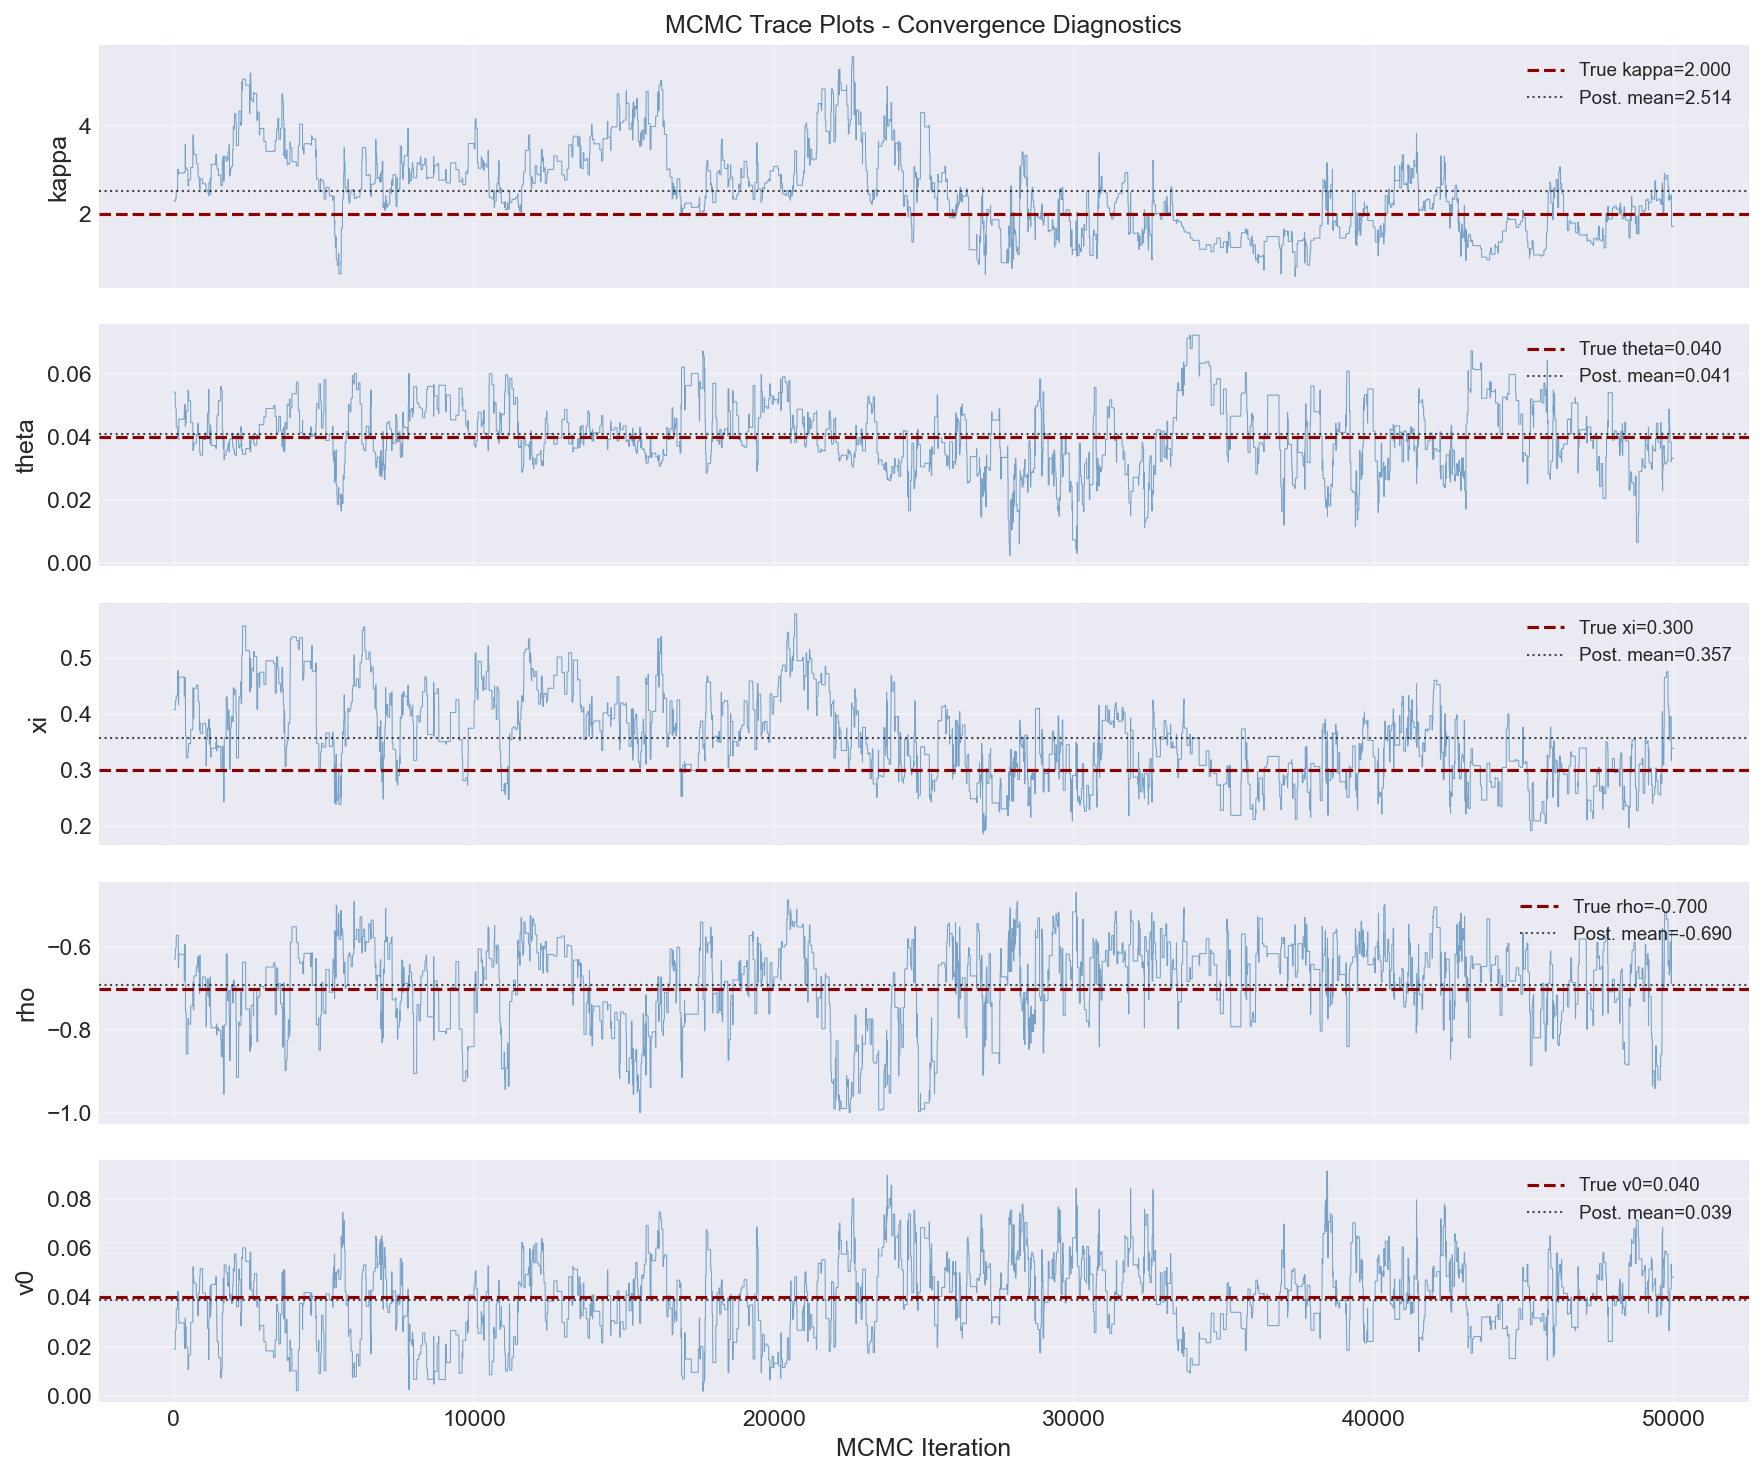


Trace plot interpretation:
  ✓ Rapid oscillation around stable mean → good mixing
  ✓ No visible trends or drifts → stationarity achieved
  ✓ Fuzzy caterpillar appearance → efficient sampling


In [6]:
# Plot trace plots
fig = plot_trace(
    samples=result.samples,
    param_names=result.param_names,
    true_params=true_params_dict,
    figsize=(12, 10),
    save_path=str(FIGURES_DIR / "trace_plots.png"),
    show=True,
)

print("\nTrace plot interpretation:")
print("  ✓ Rapid oscillation around stable mean → good mixing")
print("  ✓ No visible trends or drifts → stationarity achieved")
print("  ✓ Fuzzy caterpillar appearance → efficient sampling")

## 7. Posterior Densities

Marginal posterior distributions for each parameter. Narrow, well-separated
peaks indicate well-identified parameters.

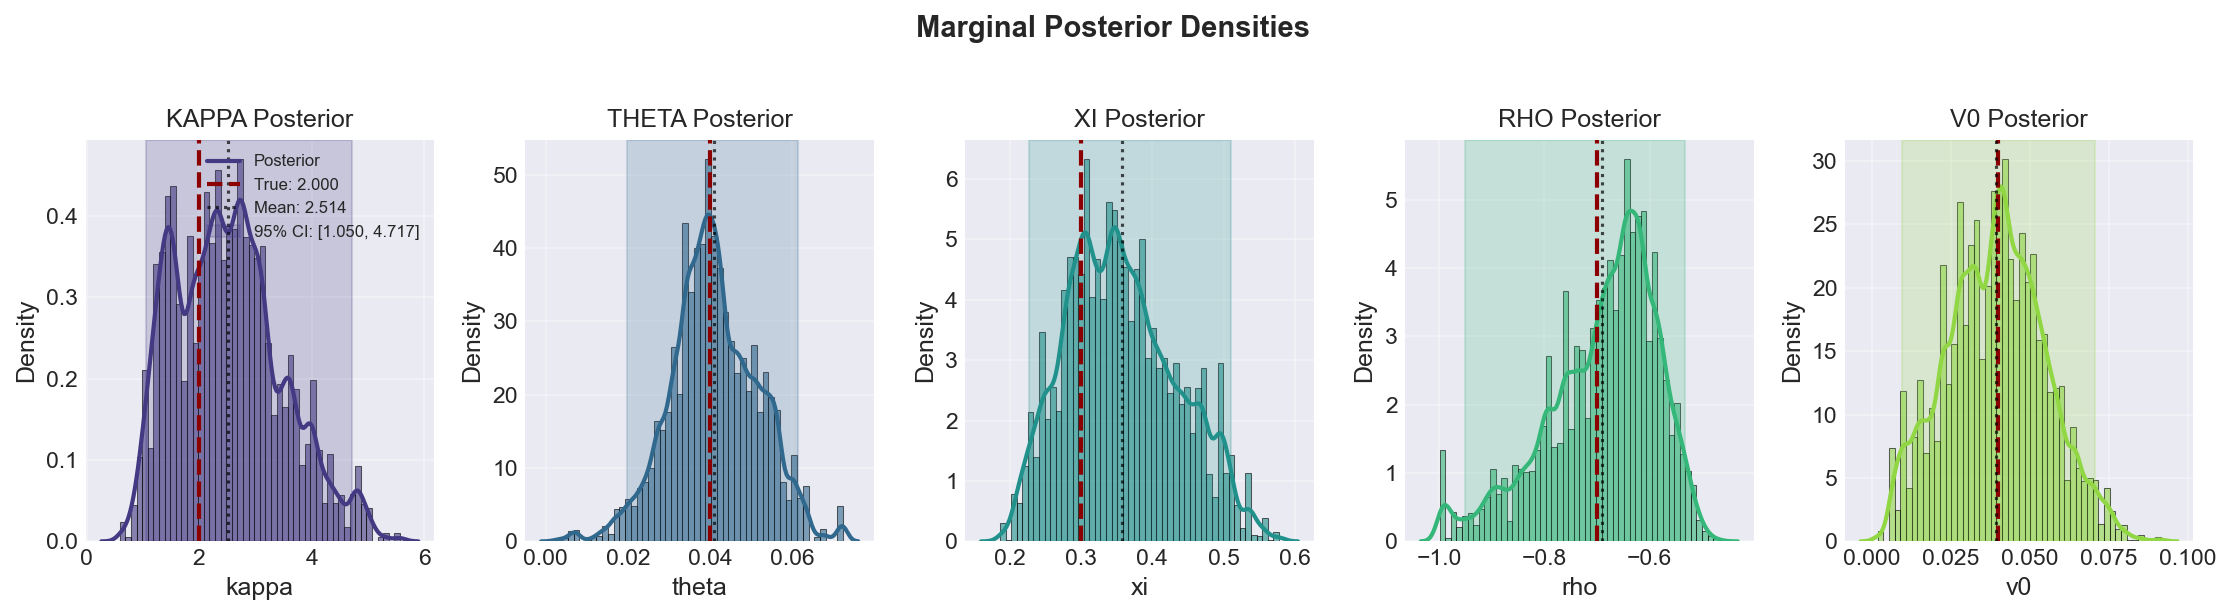


Posterior interpretation:
  ✓ θ (theta) and v₀ → tightly constrained (well-identified)
  ✓ ξ (xi) and ρ → moderate uncertainty
  ✓ κ (kappa) → often wider (poorly identified with single maturity)


In [7]:
# Plot posterior densities
fig = plot_posterior_density(
    samples=result.samples,
    param_names=result.param_names,
    true_params=true_params_dict,
    figsize=(15, 4),
    bins=50,
    kde=True,
    save_path=str(FIGURES_DIR / "posterior_densities.png"),
    show=True,
)

print("\nPosterior interpretation:")
print("  ✓ θ (theta) and v₀ → tightly constrained (well-identified)")
print("  ✓ ξ (xi) and ρ → moderate uncertainty")
print("  ✓ κ (kappa) → often wider (poorly identified with single maturity)")

## 8. Parameter Correlations (Pair Plot)

Visualises the joint posterior distribution showing parameter correlations.
Strong correlations (|r| > 0.7) indicate identifiability issues.

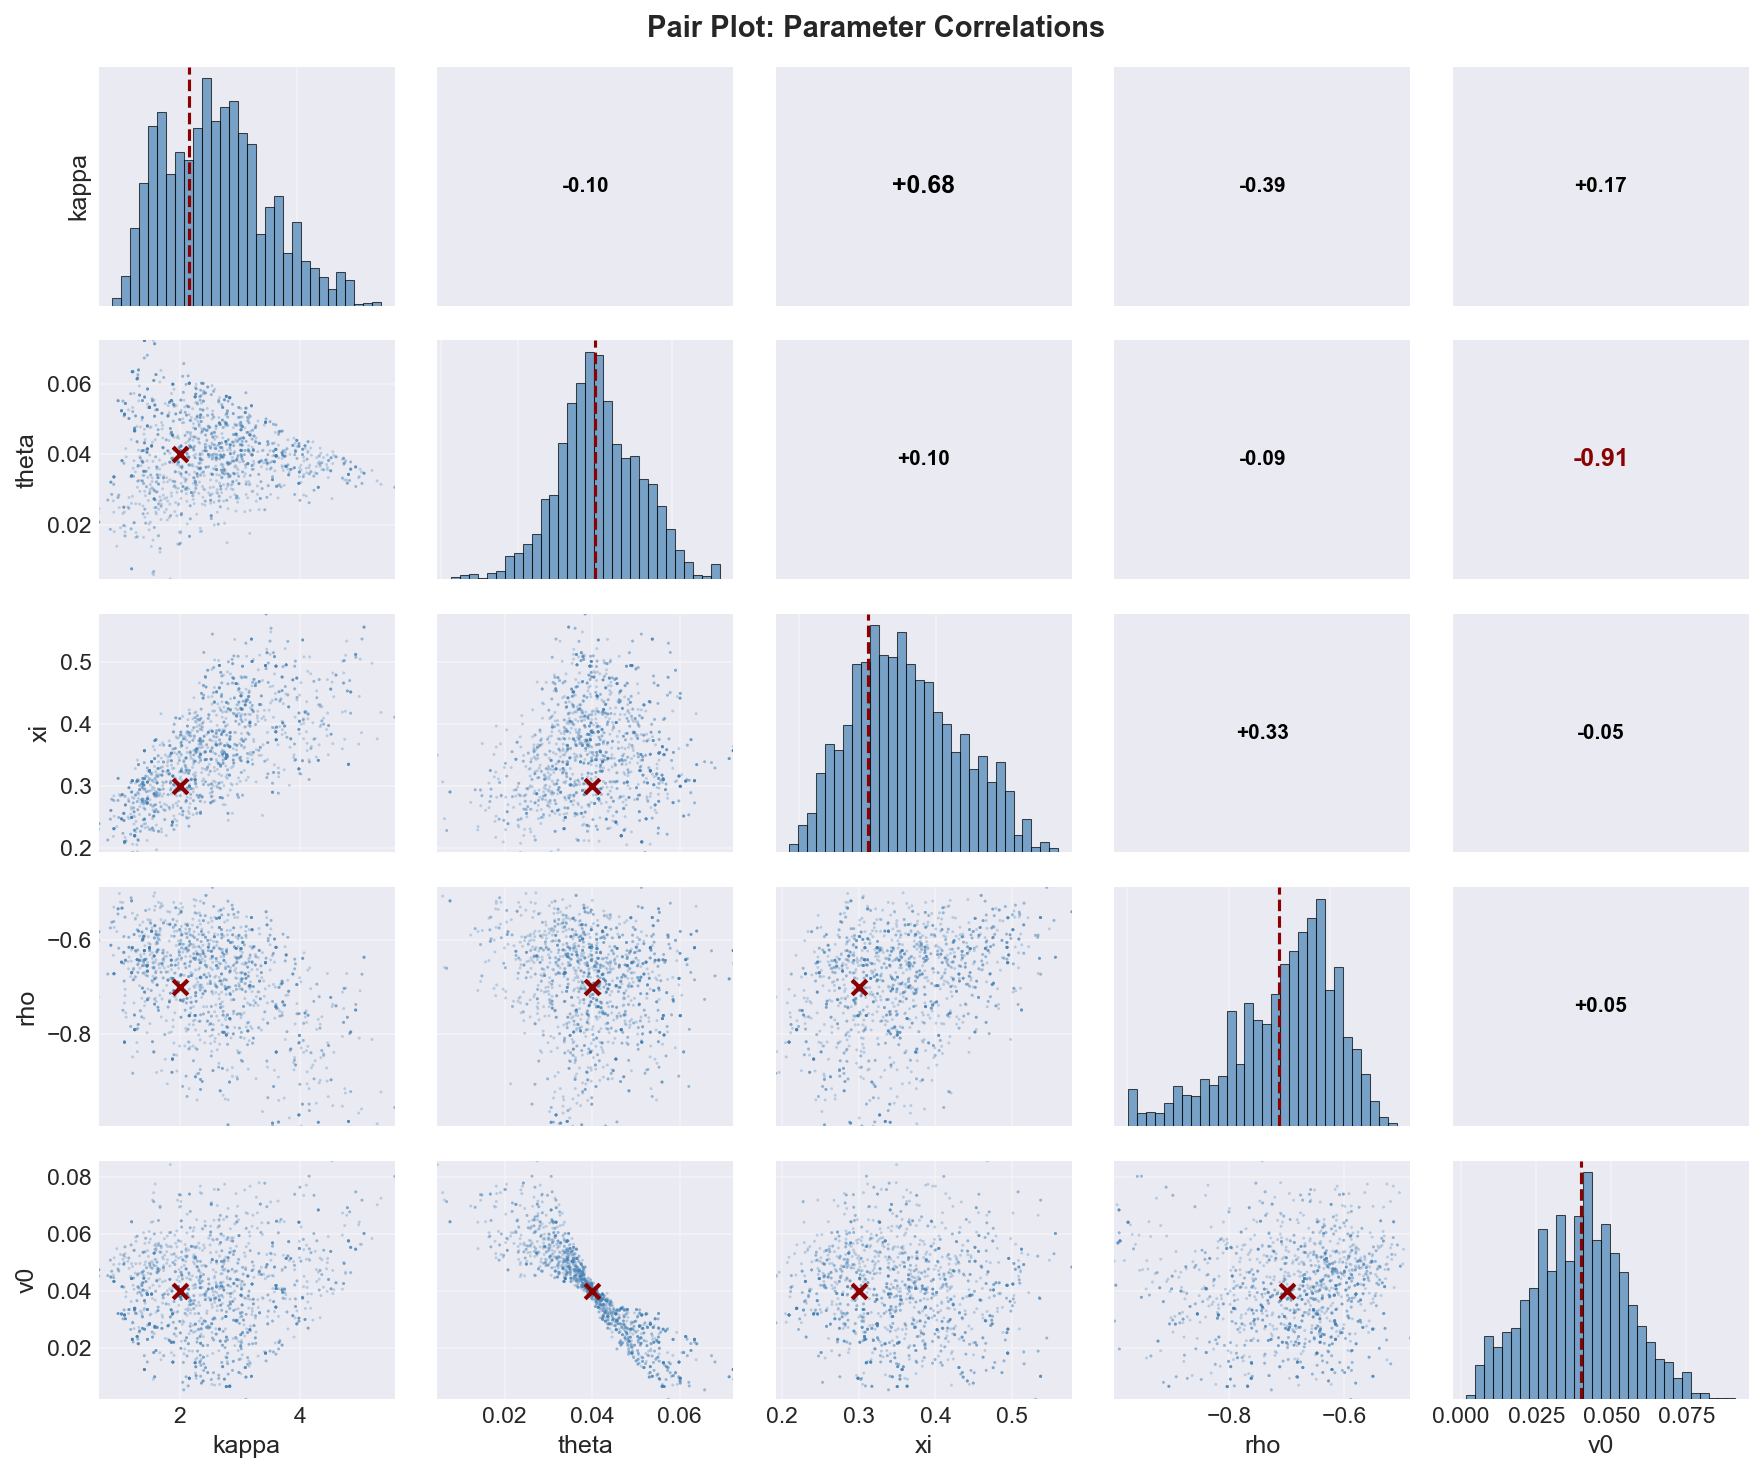


Correlation interpretation:
  ✓ Strong correlations (|r| > 0.7) → identifiability issues
  ✓ κ vs v₀ often negatively correlated
  ✓ κ vs θ can be positively correlated


In [8]:
# Plot pair plot
fig = plot_pair_grid(
    samples=result.samples,
    param_names=result.param_names,
    true_params=true_params_dict,
    figsize=(12, 10),
    alpha=0.3,
    s=2.0,
    save_path=str(FIGURES_DIR / "pair_plot.png"),
    show=True,
)

print("\nCorrelation interpretation:")
print("  ✓ Strong correlations (|r| > 0.7) → identifiability issues")
print("  ✓ κ vs v₀ often negatively correlated")
print("  ✓ κ vs θ can be positively correlated")

## 9. Posterior Predictive Check

The most important visual validation: does the calibrated model reproduce
the observed option prices?

Strike grid range: [76.0000, 126.0000]
All strikes positive: True


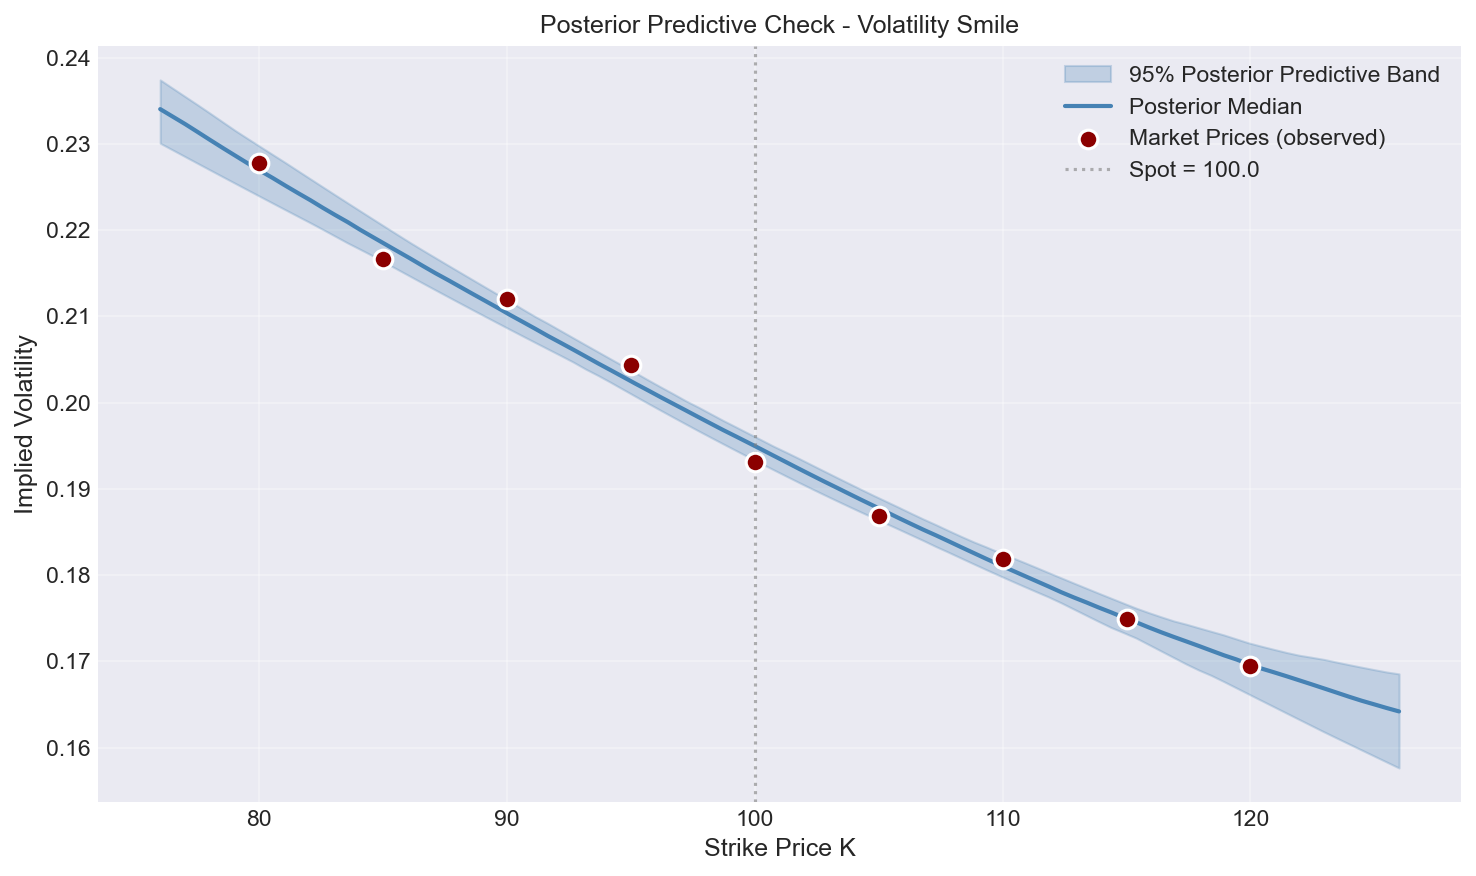


Posterior predictive interpretation:
  ✓ Observed points within 95% band → good model fit
  ✓ Band width reflects parameter uncertainty
  ✓ No systematic bias → calibration successful


In [9]:
# Plot posterior predictive check
# Ensure strike grid has only positive values (strictly > 0)
K_min = max(market_data.strikes.min() * 0.95, 1e-6)  # Use 1e-6 instead of 0.01
K_max = market_data.strikes.max() * 1.05
K_grid = np.linspace(K_min, K_max, 100)

# Ensure all strikes are positive (add small epsilon if needed)
if np.any(K_grid <= 0):
    # If any strike is <= 0, adjust the grid
    K_grid = K_grid[K_grid > 0]
    if len(K_grid) < 10:
        # If too few points, regenerate with higher min
        K_min = market_data.strikes.min() * 0.9
        K_grid = np.linspace(K_min, K_max, 100)

print(f"Strike grid range: [{K_grid.min():.4f}, {K_grid.max():.4f}]")
print(f"All strikes positive: {np.all(K_grid > 0)}")

fig = plot_posterior_predictive(
    result=result,
    market_data=market_data,
    cred_mass=0.95,
    K_grid=K_grid,  # Pass explicit positive grid
    figsize=(10, 6),
    save_path=str(FIGURES_DIR / "posterior_predictive.png"),
    show=True,
)

print("\nPosterior predictive interpretation:")
print("  ✓ Observed points within 95% band → good model fit")
print("  ✓ Band width reflects parameter uncertainty")
print("  ✓ No systematic bias → calibration successful")

## 9. Summary Dashboard

Comprehensive single-figure summary of the calibration results.

c:\Users\User\Desktop\Bayesian Calibration of the Heston Model\notebooks\..\src\visualization.py:745: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


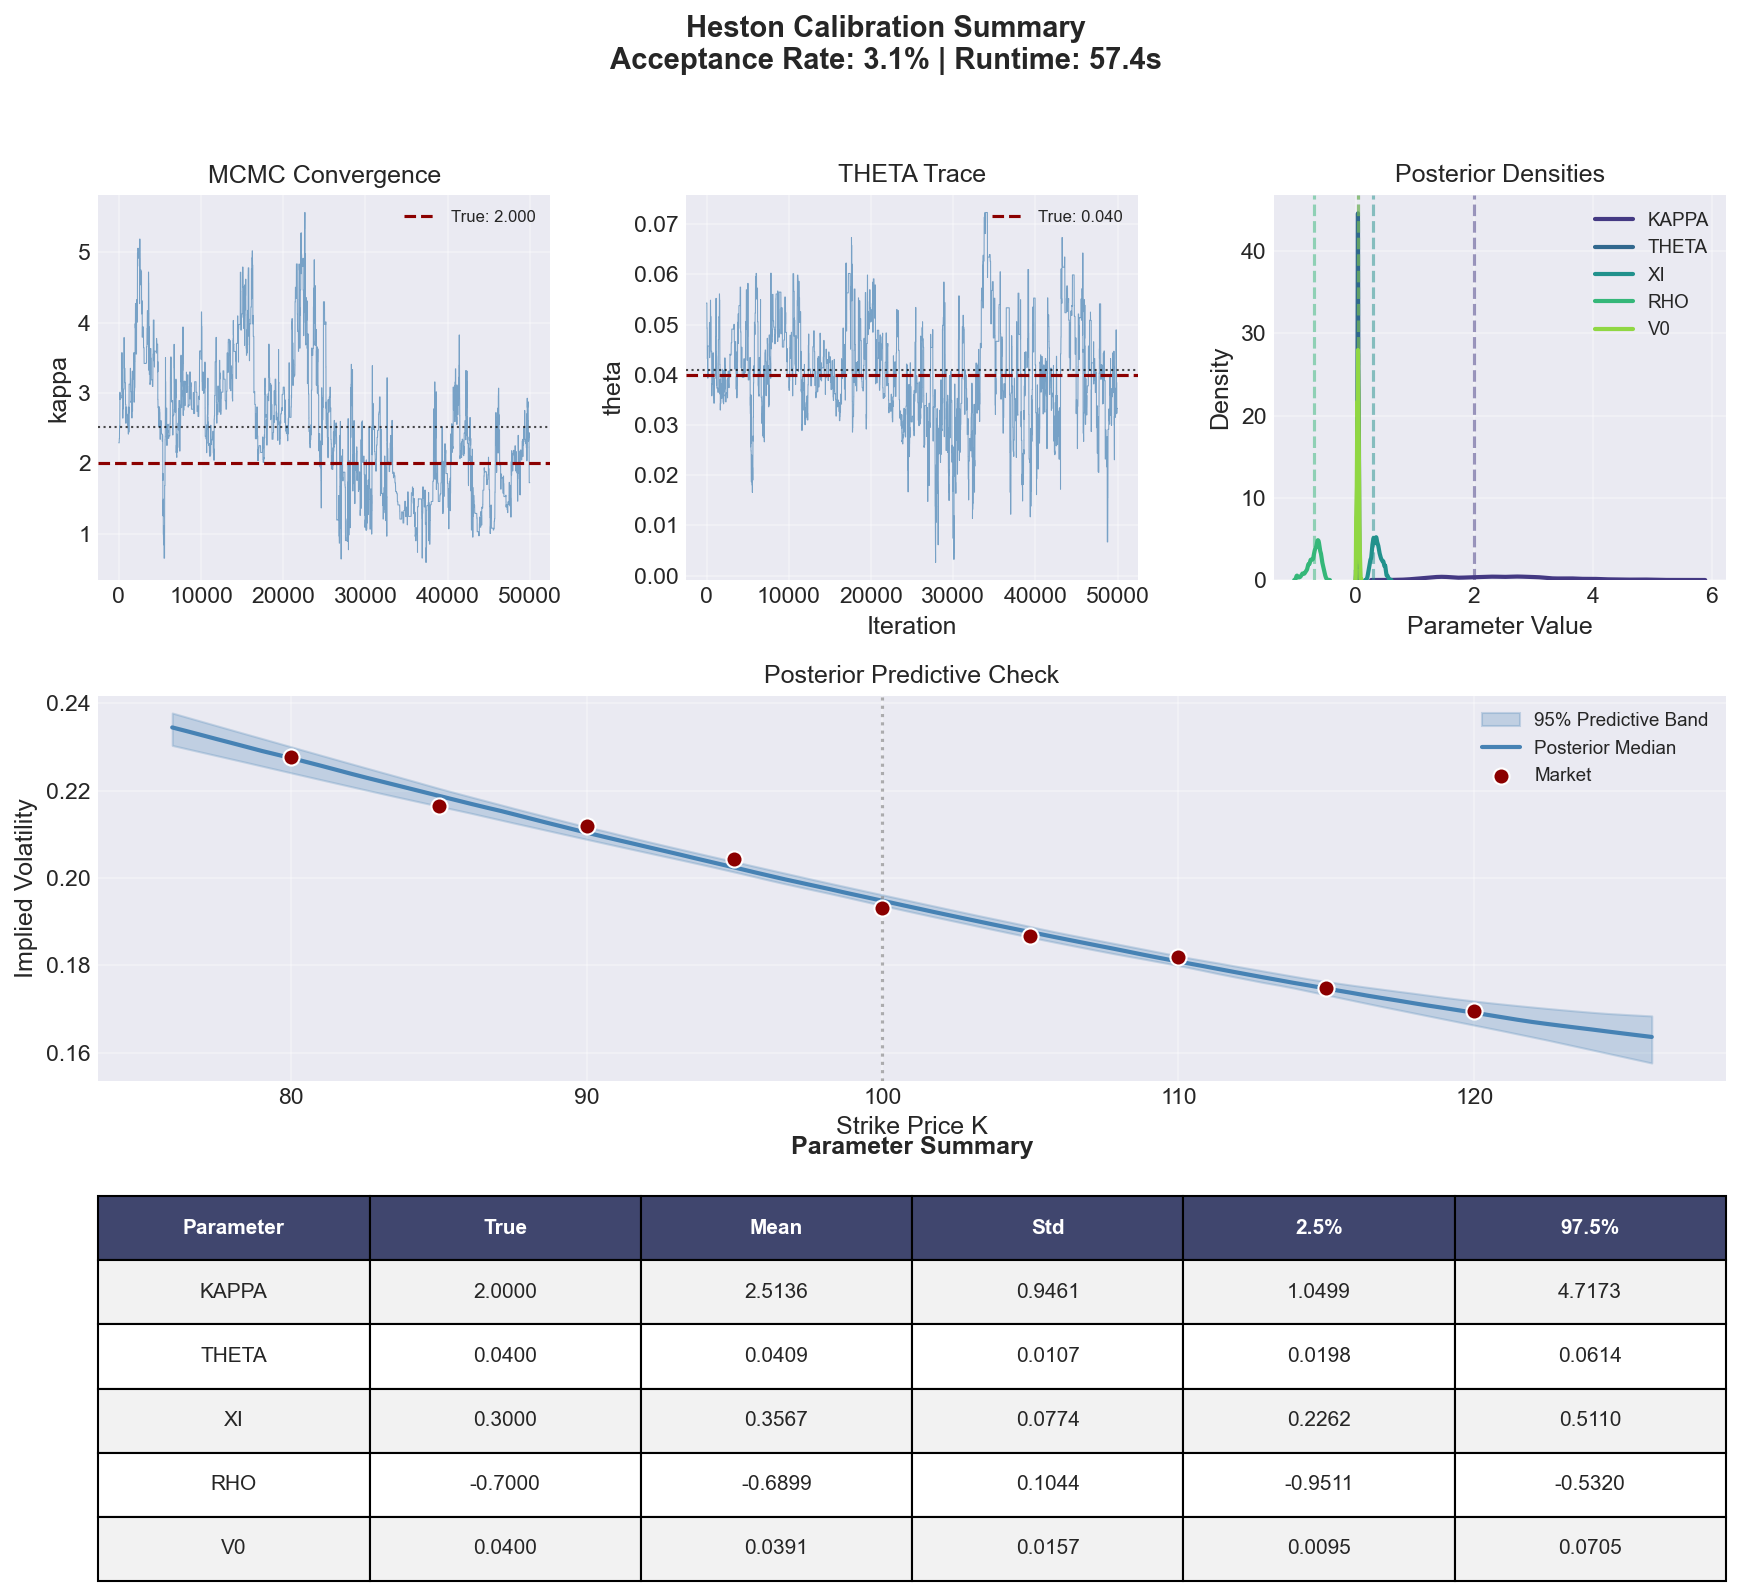


CALIBRATION COMPLETE
Results saved to: ..\results\chains\calibration_result_20260518_120023.npz
Figures saved to: ..\results\figures


In [10]:
# Create comprehensive summary dashboard
fig = plot_calibration_summary(
    result=result,
    market_data=market_data,
    figsize=(14, 12),
    save_path=str(FIGURES_DIR / "calibration_summary.png"),
    show=True,
)

print("\n" + "=" * 60)
print("CALIBRATION COMPLETE")
print("=" * 60)
print(f"Results saved to: {result_path}")
print(f"Figures saved to: {FIGURES_DIR}")
print("=" * 60)

## 9. Next Steps

The calibration results can now be analysed further in:

1. **03_analysis.ipynb** - In-depth posterior analysis and validation
2. **Real market data** - Replace synthetic data with actual market quotes
3. **Multi-maturity calibration** - Extend to multiple expiries
4. **Alternative models** - Test Bates, Heston-Hull-White, or rough volatility

---

**Notebook completed successfully.**